# Synthetic datasets evaluation on Adult dataset.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

# stdlib
import os
import sys
from pathlib import Path
import random

sys.path.append('..')
sys.path.append('../libs/MIA-synthetic-main')
os.environ['OMP_PATH'] = '/opt/homebrew/Cellar/libomp/19.1.3/include'

os.environ["SYNTHCITY_DEVICE"] = 'cuda:1'
from synthcity.utils.constants import DEVICE

# third-party
import pandas as pd
import numpy as np

from tapas.datasets import TabularDataset

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from synthcity.plugins.core.dataloader import GenericDataLoader
from synthcity.metrics.eval_statistical import AlphaPrecision

from reprosyn.methods import DS_BAYNET
from sdmetrics.reports.single_table import QualityReport
from hydra import initialize, compose

# custom
from tools.synthetic_evaluation.quality_evaluation import convert_metadata_to_sdm_format
from tools.synthetic_evaluation.classification_optimizer import ClassificationOptimizer
from tools.tapas.utils import get_categorical_and_numerical_features
from tools.tapas.tapas_data_processors import AdultDataProcessor

from tools.tapas.generators import SynthcityGenerator

/home/colin/miniconda3/envs/tapas-upgrade/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
E0000 00:00:1738862821.390350  207061 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738862821.395078  207061 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
os.getcwd()

'/home/colin/colin-pelletier/privacy/notebooks'

In [3]:
os.chdir('../')

In [ ]:
DATASET_NAME = 'adult'
RANDOM_STATE=42
gen = SynthcityGenerator("ddpm", label="TabDDPM", random_state=RANDOM_STATE,
                    lr=0.00013067363723152697,
                    batch_size=2048,
                    n_iter=1000,
                    num_timesteps=100,
                    model_params={
                        'n_layers_hidden': 4,
                        'n_units_hidden':128,
                        'dropout': 0.000871018582934785
                    })
CLF_CONFIG = f'{DATASET_NAME}_best'
GENERATOR_ID = "TabDDPM" # to export model comparison results

# reproducibility
np.random.seed(RANDOM_STATE)
pd.np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# for final dataset display
results = []

# IO
DATA_FOLDER = Path('./data')
OUTPUT_FOLDER = Path('./generated/generators_comparison')
OUTPUT_FOLDER_EDA = OUTPUT_FOLDER/'eda'
# from ./privacy
PRIVACY_EXPERIMENT_DIR = "./experiments/privacy"

# 1k experiment

## Load data

In [6]:
N_SYNTH_SAMPLES = 1000
N_TEST_SAMPLES = 200

DATASET_NAME = 'adult'
DATA_PATH = Path(f'./data/{DATASET_NAME}')
full_ds = TabularDataset.read(DATA_PATH, label=DATASET_NAME)
full_ds = AdultDataProcessor.process_tapas_tabulardataset(full_ds)
categorical_features = full_ds.description.one_hot_cols
numerical_features = [col for col in full_ds.description.columns if col not in categorical_features]

# pre-define test samples for ML utility
np_rng = np.random.default_rng(RANDOM_STATE)
record_ids = np_rng.integers(0, len(full_ds.data), N_SYNTH_SAMPLES+N_TEST_SAMPLES)
train_records_ids = record_ids[:N_SYNTH_SAMPLES]
test_records_ids = record_ids[N_SYNTH_SAMPLES:]
test_ds = full_ds.get_records(test_records_ids)
train_ds = full_ds.get_records(train_records_ids)

results_exp = {
    'N_SYNTH_SAMPLES': N_SYNTH_SAMPLES,
    'N_TEST_SAMPLES': N_TEST_SAMPLES,
    'DATASET_NAME': DATASET_NAME
    }

## Generate synthetic datasets

In [7]:
gen.fit(train_ds)
synth_data = gen.generate(N_SYNTH_SAMPLES)

# 5k iter: 33it/s, takes 2min30sec per dataset, loss=1.39, cv_score=0.72, similarity=0.7
# 1k iter: 33it/s, takes 30sec per dataset, loss=2.04, cv_score=0.78, similarity=0.69

# time estimate: 

[2025-02-06T18:27:05.677568+0100][207061][CRITICAL] load failed: Failed to import transformers.trainer because of the following error (look up to see its traceback):
Failed to import transformers.integrations.integration_utils because of the following error (look up to see its traceback):
Failed to import transformers.modeling_tf_utils because of the following error (look up to see its traceback):
Your currently installed version of Keras is Keras 3, but this is not yet supported in Transformers. Please install the backwards-compatible tf-keras package with `pip install tf-keras`.
[2025-02-06T18:27:05.679074+0100][207061][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2025-02-06T18:27:05.679652+0100][207061][CRITICAL] module plugin_great load failed
[2025-02-06T18:27:05.745306+0100][207061][CRITICAL] module disabled: /home/colin/miniconda3/envs/tapas-upgrade/lib/python3.10/site-packages/synthcity/plugins/generic/plugin_goggle.py
Epoch:

## Statistical similarity evaluation

In [8]:
full_ds.description.schema = [{'name': 'age',
  'type': 'Integer',
  'representation': 'number',
  'min': 0,
  'max': 90},
 {'name': 'workclass',
  'type': 'finite',
  'representation': ['Private',
   'Self-emp-not-inc',
   'Self-emp-inc',
   'Federal-gov',
   'Local-gov',
   'State-gov',
   'Without-pay']},
 {'name': 'fnlwgt',
  'type': 'Float',
  'representation': 'number',
  'min': 13492.0,
  'max': 1490400.0},
 {'name': 'education',
  'type': 'finite',
  'representation': ['Bachelors',
   'Some-college',
   '11th',
   'HS-grad',
   'Prof-school',
   'Assoc-acdm',
   'Assoc-voc',
   '9th',
   '7th-8th',
   '12th',
   'Masters',
   '1st-4th',
   '10th',
   'Doctorate',
   '5th-6th',
   'Preschool']},
 {'name': 'education-num',
  'type': 'Integer',
  'representation': 'number',
  'min': 1,
  'max': 16},
 {'name': 'marital-status',
  'type': 'finite',
  'representation': ['Married-civ-spouse',
   'Divorced',
   'Never-married',
   'Separated',
   'Widowed',
   'Married-spouse-absent',
   'Married-AF-spouse']},
 {'name': 'occupation',
  'type': 'finite',
  'representation': ['Tech-support',
   'Craft-repair',
   'Other-service',
   'Sales',
   'Exec-managerial',
   'Prof-specialty',
   'Handlers-cleaners',
   'Machine-op-inspct',
   'Adm-clerical',
   'Farming-fishing',
   'Transport-moving',
   'Priv-house-serv',
   'Protective-serv',
   'Armed-Forces']},
 {'name': 'relationship',
  'type': 'finite',
  'representation': ['Wife',
   'Own-child',
   'Husband',
   'Not-in-family',
   'Other-relative',
   'Unmarried']},
 {'name': 'race',
  'type': 'finite',
  'representation': ['White',
   'Asian-Pac-Islander',
   'Amer-Indian-Eskimo',
   'Other',
   'Black']},
 {'name': 'sex', 'type': 'finite', 'representation': ['Female', 'Male']},
 {'name': 'capital-gain',
  'type': 'Float',
  'representation': 'number',
  'min': 0.0,
  'max': 99999.0},
 {'name': 'capital-loss',
  'type': 'Float',
  'representation': 'number',
  'min': 0.0,
  'max': 4356.0},
 {'name': 'hours-per-week',
  'type': 'Float',
  'representation': 'number',
  'min': 1.0,
  'max': 99.0},
 {'name': 'native-country',
  'type': 'finite',
  'representation': ['United-States',
   'Cambodia',
   'England',
   'Puerto-Rico',
   'Canada',
   'Germany',
   'Outlying-US(Guam-USVI-etc)',
   'India',
   'Japan',
   'Greece',
   'South',
   'China',
   'Cuba',
   'Iran',
   'Honduras',
   'Philippines',
   'Italy',
   'Poland',
   'Jamaica',
   'Vietnam',
   'Mexico',
   'Portugal',
   'Ireland',
   'France',
   'Dominican-Republic',
   'Laos',
   'Ecuador',
   'Taiwan',
   'Haiti',
   'Columbia',
   'Hungary',
   'Guatemala',
   'Nicaragua',
   'Scotland',
   'Thailand',
   'Yugoslavia',
   'El-Salvador',
   'Trinadad&Tobago',
   'Peru',
   'Hong',
   'Holand-Netherlands']},
 {'name': 'income', 'type': 'finite', 'representation': ['>50K', '<=50K']}]

In [9]:
metadata = convert_metadata_to_sdm_format(full_ds.description.schema)
quality_report = QualityReport()
quality_report.generate(train_ds.data, synth_data.data, metadata)
fig = quality_report.get_visualization(property_name='Column Shapes')
fig.show()


results_exp['Column Pair Trends'] = quality_report.get_details('Column Pair Trends').mean()['Score']
results_exp['Column Shapes'] = quality_report.get_details('Column Shapes').mean()['Score']

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 669.28it/s]|
Column Shapes Score: 68.72%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 222.91it/s]|
Column Pair Trends Score: 49.08%

Overall Score (Average): 58.9%



## ML Utility

In [ ]:
# Use hydra configuration file with the optimal hyperparameters
with initialize(config_path="../configs/classifier_hpo", version_base=None):
    cfg = compose(config_name=CLF_CONFIG)

clf_opt = ClassificationOptimizer(cfg, synth_data, test_ds)
clf_opt.fit()

cv_scores_mean, cv_scores_std = clf_opt.evaluate_classifier()
test_scores_mean, test_scores_low_ci, test_scores_high_ci = clf_opt.test_classifier(n_repetitions=100)
results_exp['CV Mean'] = cv_scores_mean
results_exp['CV Std'] = cv_scores_std
results_exp['Test Mean'] = test_scores_mean
results_exp['Test Low CI'] = test_scores_low_ci
results_exp['Test High CI'] = test_scores_high_ci

print(f"CV scores mean: {cv_scores_mean:.3f} (+/- {cv_scores_std:.3f})")
print(f"Test scores mean: {test_scores_mean:.3f} ({test_scores_low_ci:.3f}-{test_scores_high_ci:.3f})")

CV scores mean: 0.804 (+/- 0.025)
Test scores mean: 0.724 (0.650-0.774)


## Authenticity

In [11]:
def encode_features(dataset):
    data_description = dataset.description
    df = dataset.data.copy()
    categorical_features, numerical_features = get_categorical_and_numerical_features(data_description)
    categories = {col["name"]: col["representation"] for col in data_description if col['name'] in categorical_features}
    categories = [categories[col] for col in dataset.data.columns if col in categorical_features]
    ohe = OneHotEncoder(sparse_output=False, categories=categories, handle_unknown='ignore')

    preprocessor = ColumnTransformer([
        ('numerical', StandardScaler(), numerical_features),
        ('categorical', ohe, categorical_features)
    ])

    return preprocessor.fit_transform(df)

train_loader = GenericDataLoader(encode_features(train_ds), random_state=RANDOM_STATE)
synth_loader = GenericDataLoader(encode_features(synth_data), random_state=RANDOM_STATE)

alpha_precision = AlphaPrecision()
alpha_precision = alpha_precision.evaluate(train_loader, synth_loader)

results_exp['Authenticity'] = alpha_precision['authenticity_OC']
print("Authenticity:", alpha_precision['authenticity_OC'])

results.append(results_exp)

Authenticity: 0.927


In [12]:
pd.DataFrame(results_exp, index=[DATASET_NAME]).round(3)

,N_SYNTH_SAMPLES,N_TEST_SAMPLES,DATASET_NAME,Column Pair Trends,Column Shapes,CV Mean,CV Std,Test Mean,Test Low CI,Test High CI,Authenticity
adult,1000,200,adult,0.491,0.687,0.804,0.025,0.724,0.65,0.774,0.927


# 10k experiment

## Load data

In [13]:
N_SYNTH_SAMPLES = 10000
N_TEST_SAMPLES = 2000

DATASET_NAME = 'adult'
DATA_PATH = Path(f'./data/{DATASET_NAME}')
full_ds = TabularDataset.read(DATA_PATH, label=DATASET_NAME)
full_ds = AdultDataProcessor.process_tapas_tabulardataset(full_ds)
categorical_features = full_ds.description.one_hot_cols
numerical_features = [col for col in full_ds.description.columns if col not in categorical_features]

# pre-define test samples for ML utility
np_rng = np.random.default_rng(RANDOM_STATE)
record_ids = np_rng.integers(0, len(full_ds.data), N_SYNTH_SAMPLES+N_TEST_SAMPLES)
train_records_ids = record_ids[:N_SYNTH_SAMPLES]
test_records_ids = record_ids[N_SYNTH_SAMPLES:]
test_ds = full_ds.get_records(test_records_ids)
train_ds = full_ds.get_records(train_records_ids)

results_exp = {
    'N_SYNTH_SAMPLES': N_SYNTH_SAMPLES,
    'N_TEST_SAMPLES': N_TEST_SAMPLES,
    'DATASET_NAME': DATASET_NAME
    }

## Generate synthetic datasets

In [14]:
gen.fit(train_ds)
synth_data = gen.generate(N_SYNTH_SAMPLES)

[2025-02-06T18:27:45.740699+0100][207061][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2025-02-06T18:27:45.741762+0100][207061][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2025-02-06T18:27:45.742497+0100][207061][CRITICAL] module plugin_great load failed
[2025-02-06T18:27:45.743291+0100][207061][CRITICAL] module disabled: /home/colin/miniconda3/envs/tapas-upgrade/lib/python3.10/site-packages/synthcity/plugins/generic/plugin_goggle.py
Epoch: 100%|██████████| 1000/1000 [03:32<00:00,  4.70it/s, loss=1.57]


## Statistical similarity evaluation

In [16]:
full_ds.description.schema = [{'name': 'age',
  'type': 'Integer',
  'representation': 'number',
  'min': 0,
  'max': 90},
 {'name': 'workclass',
  'type': 'finite',
  'representation': ['Private',
   'Self-emp-not-inc',
   'Self-emp-inc',
   'Federal-gov',
   'Local-gov',
   'State-gov',
   'Without-pay']},
 {'name': 'fnlwgt',
  'type': 'Float',
  'representation': 'number',
  'min': 13492.0,
  'max': 1490400.0},
 {'name': 'education',
  'type': 'finite',
  'representation': ['Bachelors',
   'Some-college',
   '11th',
   'HS-grad',
   'Prof-school',
   'Assoc-acdm',
   'Assoc-voc',
   '9th',
   '7th-8th',
   '12th',
   'Masters',
   '1st-4th',
   '10th',
   'Doctorate',
   '5th-6th',
   'Preschool']},
 {'name': 'education-num',
  'type': 'Integer',
  'representation': 'number',
  'min': 1,
  'max': 16},
 {'name': 'marital-status',
  'type': 'finite',
  'representation': ['Married-civ-spouse',
   'Divorced',
   'Never-married',
   'Separated',
   'Widowed',
   'Married-spouse-absent',
   'Married-AF-spouse']},
 {'name': 'occupation',
  'type': 'finite',
  'representation': ['Tech-support',
   'Craft-repair',
   'Other-service',
   'Sales',
   'Exec-managerial',
   'Prof-specialty',
   'Handlers-cleaners',
   'Machine-op-inspct',
   'Adm-clerical',
   'Farming-fishing',
   'Transport-moving',
   'Priv-house-serv',
   'Protective-serv',
   'Armed-Forces']},
 {'name': 'relationship',
  'type': 'finite',
  'representation': ['Wife',
   'Own-child',
   'Husband',
   'Not-in-family',
   'Other-relative',
   'Unmarried']},
 {'name': 'race',
  'type': 'finite',
  'representation': ['White',
   'Asian-Pac-Islander',
   'Amer-Indian-Eskimo',
   'Other',
   'Black']},
 {'name': 'sex', 'type': 'finite', 'representation': ['Female', 'Male']},
 {'name': 'capital-gain',
  'type': 'Float',
  'representation': 'number',
  'min': 0.0,
  'max': 99999.0},
 {'name': 'capital-loss',
  'type': 'Float',
  'representation': 'number',
  'min': 0.0,
  'max': 4356.0},
 {'name': 'hours-per-week',
  'type': 'Float',
  'representation': 'number',
  'min': 1.0,
  'max': 99.0},
 {'name': 'native-country',
  'type': 'finite',
  'representation': ['United-States',
   'Cambodia',
   'England',
   'Puerto-Rico',
   'Canada',
   'Germany',
   'Outlying-US(Guam-USVI-etc)',
   'India',
   'Japan',
   'Greece',
   'South',
   'China',
   'Cuba',
   'Iran',
   'Honduras',
   'Philippines',
   'Italy',
   'Poland',
   'Jamaica',
   'Vietnam',
   'Mexico',
   'Portugal',
   'Ireland',
   'France',
   'Dominican-Republic',
   'Laos',
   'Ecuador',
   'Taiwan',
   'Haiti',
   'Columbia',
   'Hungary',
   'Guatemala',
   'Nicaragua',
   'Scotland',
   'Thailand',
   'Yugoslavia',
   'El-Salvador',
   'Trinadad&Tobago',
   'Peru',
   'Hong',
   'Holand-Netherlands']},
 {'name': 'income', 'type': 'finite', 'representation': ['>50K', '<=50K']}]

In [17]:
metadata = convert_metadata_to_sdm_format(full_ds.description.schema)
quality_report = QualityReport()
quality_report.generate(train_ds.data, synth_data.data, metadata)
fig = quality_report.get_visualization(property_name='Column Shapes')
fig.show()
quality_report


results_exp['Column Pair Trends'] = quality_report.get_details('Column Pair Trends').mean()['Score']
results_exp['Column Shapes'] = quality_report.get_details('Column Shapes').mean()['Score']

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 249.42it/s]|
Column Shapes Score: 67.28%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 162.50it/s]|
Column Pair Trends Score: 49.36%

Overall Score (Average): 58.32%



## ML Utility

In [ ]:
# Use hydra configuration file with the optimal hyperparameters
with initialize(config_path="../configs/classifier_hpo", version_base=None):
    cfg = compose(config_name=CLF_CONFIG)

clf_opt = ClassificationOptimizer(cfg, synth_data, test_ds)
clf_opt.fit()

cv_scores_mean, cv_scores_std = clf_opt.evaluate_classifier()
test_scores_mean, test_scores_low_ci, test_scores_high_ci = clf_opt.test_classifier(n_repetitions=100)
results_exp['CV Mean'] = cv_scores_mean
results_exp['CV Std'] = cv_scores_std
results_exp['Test Mean'] = test_scores_mean
results_exp['Test Low CI'] = test_scores_low_ci
results_exp['Test High CI'] = test_scores_high_ci

print(f"CV scores mean: {cv_scores_mean:.3f} (+/- {cv_scores_std:.3f})")
print(f"Test scores mean: {test_scores_mean:.3f} ({test_scores_low_ci:.3f}-{test_scores_high_ci:.3f})")

CV scores mean: 0.863 (+/- 0.007)
Test scores mean: 0.658 (0.637-0.683)


## Authenticity

In [19]:
def encode_features(dataset):
    data_description = dataset.description
    df = dataset.data.copy()
    categorical_features, numerical_features = get_categorical_and_numerical_features(data_description)
    categories = {col["name"]: col["representation"] for col in data_description if col['name'] in categorical_features}
    categories = [categories[col] for col in dataset.data.columns if col in categorical_features]
    ohe = OneHotEncoder(sparse_output=False, categories=categories, handle_unknown='ignore')

    preprocessor = ColumnTransformer([
        ('numerical', StandardScaler(), numerical_features),
        ('categorical', ohe, categorical_features)
    ])

    return preprocessor.fit_transform(df)

train_loader = GenericDataLoader(encode_features(train_ds), random_state=RANDOM_STATE)
synth_loader = GenericDataLoader(encode_features(synth_data), random_state=RANDOM_STATE)

alpha_precision = AlphaPrecision()
alpha_precision = alpha_precision.evaluate(train_loader, synth_loader)

results_exp['Authenticity'] = alpha_precision['authenticity_OC']
print("Authenticity:", alpha_precision['authenticity_OC'])

results.append(results_exp)

Authenticity: 0.8936


In [20]:
pd.DataFrame(results_exp, index=[DATASET_NAME]).round(3)

,N_SYNTH_SAMPLES,N_TEST_SAMPLES,DATASET_NAME,Column Pair Trends,Column Shapes,CV Mean,CV Std,Test Mean,Test Low CI,Test High CI,Authenticity
adult,10000,2000,adult,0.494,0.673,0.863,0.007,0.658,0.637,0.683,0.894


# 30k experiment

## Load data

In [21]:
N_SYNTH_SAMPLES = 30000
N_TEST_SAMPLES = 5000

DATASET_NAME = 'adult'
DATA_PATH = Path(f'./data/{DATASET_NAME}')
full_ds = TabularDataset.read(DATA_PATH, label=DATASET_NAME)
full_ds = AdultDataProcessor.process_tapas_tabulardataset(full_ds)
categorical_features = full_ds.description.one_hot_cols
numerical_features = [col for col in full_ds.description.columns if col not in categorical_features]

# pre-define test samples for ML utility
np_rng = np.random.default_rng(RANDOM_STATE)
record_ids = np_rng.integers(0, len(full_ds.data), N_SYNTH_SAMPLES+N_TEST_SAMPLES)
train_records_ids = record_ids[:N_SYNTH_SAMPLES]
test_records_ids = record_ids[N_SYNTH_SAMPLES:]
test_ds = full_ds.get_records(test_records_ids)
train_ds = full_ds.get_records(train_records_ids)

results_exp = {
    'N_SYNTH_SAMPLES': N_SYNTH_SAMPLES,
    'N_TEST_SAMPLES': N_TEST_SAMPLES,
    'DATASET_NAME': DATASET_NAME
    }

## Generate synthetic datasets

In [22]:
gen.fit(train_ds)
synth_data = gen.generate(N_SYNTH_SAMPLES)

[2025-02-06T18:33:28.532441+0100][207061][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2025-02-06T18:33:28.533576+0100][207061][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2025-02-06T18:33:28.534248+0100][207061][CRITICAL] module plugin_great load failed
[2025-02-06T18:33:28.534961+0100][207061][CRITICAL] module disabled: /home/colin/miniconda3/envs/tapas-upgrade/lib/python3.10/site-packages/synthcity/plugins/generic/plugin_goggle.py
Epoch: 100%|██████████| 1000/1000 [10:31<00:00,  1.58it/s, loss=1.24]


## Statistical similarity evaluation

In [23]:
full_ds.description.schema = [{'name': 'age',
  'type': 'Integer',
  'representation': 'number',
  'min': 0,
  'max': 90},
 {'name': 'workclass',
  'type': 'finite',
  'representation': ['Private',
   'Self-emp-not-inc',
   'Self-emp-inc',
   'Federal-gov',
   'Local-gov',
   'State-gov',
   'Without-pay']},
 {'name': 'fnlwgt',
  'type': 'Float',
  'representation': 'number',
  'min': 13492.0,
  'max': 1490400.0},
 {'name': 'education',
  'type': 'finite',
  'representation': ['Bachelors',
   'Some-college',
   '11th',
   'HS-grad',
   'Prof-school',
   'Assoc-acdm',
   'Assoc-voc',
   '9th',
   '7th-8th',
   '12th',
   'Masters',
   '1st-4th',
   '10th',
   'Doctorate',
   '5th-6th',
   'Preschool']},
 {'name': 'education-num',
  'type': 'Integer',
  'representation': 'number',
  'min': 1,
  'max': 16},
 {'name': 'marital-status',
  'type': 'finite',
  'representation': ['Married-civ-spouse',
   'Divorced',
   'Never-married',
   'Separated',
   'Widowed',
   'Married-spouse-absent',
   'Married-AF-spouse']},
 {'name': 'occupation',
  'type': 'finite',
  'representation': ['Tech-support',
   'Craft-repair',
   'Other-service',
   'Sales',
   'Exec-managerial',
   'Prof-specialty',
   'Handlers-cleaners',
   'Machine-op-inspct',
   'Adm-clerical',
   'Farming-fishing',
   'Transport-moving',
   'Priv-house-serv',
   'Protective-serv',
   'Armed-Forces']},
 {'name': 'relationship',
  'type': 'finite',
  'representation': ['Wife',
   'Own-child',
   'Husband',
   'Not-in-family',
   'Other-relative',
   'Unmarried']},
 {'name': 'race',
  'type': 'finite',
  'representation': ['White',
   'Asian-Pac-Islander',
   'Amer-Indian-Eskimo',
   'Other',
   'Black']},
 {'name': 'sex', 'type': 'finite', 'representation': ['Female', 'Male']},
 {'name': 'capital-gain',
  'type': 'Float',
  'representation': 'number',
  'min': 0.0,
  'max': 99999.0},
 {'name': 'capital-loss',
  'type': 'Float',
  'representation': 'number',
  'min': 0.0,
  'max': 4356.0},
 {'name': 'hours-per-week',
  'type': 'Float',
  'representation': 'number',
  'min': 1.0,
  'max': 99.0},
 {'name': 'native-country',
  'type': 'finite',
  'representation': ['United-States',
   'Cambodia',
   'England',
   'Puerto-Rico',
   'Canada',
   'Germany',
   'Outlying-US(Guam-USVI-etc)',
   'India',
   'Japan',
   'Greece',
   'South',
   'China',
   'Cuba',
   'Iran',
   'Honduras',
   'Philippines',
   'Italy',
   'Poland',
   'Jamaica',
   'Vietnam',
   'Mexico',
   'Portugal',
   'Ireland',
   'France',
   'Dominican-Republic',
   'Laos',
   'Ecuador',
   'Taiwan',
   'Haiti',
   'Columbia',
   'Hungary',
   'Guatemala',
   'Nicaragua',
   'Scotland',
   'Thailand',
   'Yugoslavia',
   'El-Salvador',
   'Trinadad&Tobago',
   'Peru',
   'Hong',
   'Holand-Netherlands']},
 {'name': 'income', 'type': 'finite', 'representation': ['>50K', '<=50K']}]

In [24]:
metadata = convert_metadata_to_sdm_format(full_ds.description.schema)
quality_report = QualityReport()
quality_report.generate(train_ds.data, synth_data.data, metadata)
fig = quality_report.get_visualization(property_name='Column Shapes')
fig.show()

results_exp['Column Pair Trends'] = quality_report.get_details('Column Pair Trends').mean()['Score']
results_exp['Column Shapes'] = quality_report.get_details('Column Shapes').mean()['Score']

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 141.61it/s]|
Column Shapes Score: 86.18%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:01<00:00, 100.48it/s]|
Column Pair Trends Score: 79.47%

Overall Score (Average): 82.83%



## ML Utility

In [ ]:
# Use hydra configuration file with the optimal hyperparameters
with initialize(config_path="../configs/classifier_hpo", version_base=None):
    cfg = compose(config_name=CLF_CONFIG)

clf_opt = ClassificationOptimizer(cfg, synth_data, test_ds)
clf_opt.fit()

cv_scores_mean, cv_scores_std = clf_opt.evaluate_classifier()
test_scores_mean, test_scores_low_ci, test_scores_high_ci = clf_opt.test_classifier(n_repetitions=100)
results_exp['CV Mean'] = cv_scores_mean
results_exp['CV Std'] = cv_scores_std
results_exp['Test Mean'] = test_scores_mean
results_exp['Test Low CI'] = test_scores_low_ci
results_exp['Test High CI'] = test_scores_high_ci

print(f"CV scores mean: {cv_scores_mean:.3f} (+/- {cv_scores_std:.3f})")
print(f"Test scores mean: {test_scores_mean:.3f} ({test_scores_low_ci:.3f}-{test_scores_high_ci:.3f})")

CV scores mean: 0.869 (+/- 0.003)
Test scores mean: 0.769 (0.757-0.784)


## Authenticity

In [ ]:
def encode_features(dataset):
    data_description = dataset.description
    df = dataset.data.copy()
    categorical_features, numerical_features = get_categorical_and_numerical_features(data_description)
    categories = {col["name"]: col["representation"] for col in data_description if col['name'] in categorical_features}
    categories = [categories[col] for col in dataset.data.columns if col in categorical_features]
    ohe = OneHotEncoder(sparse_output=False, categories=categories, handle_unknown='ignore')

    preprocessor = ColumnTransformer([
        ('numerical', StandardScaler(), numerical_features),
        ('categorical', ohe, categorical_features)
    ])

    return preprocessor.fit_transform(df)

train_loader = GenericDataLoader(encode_features(train_ds), random_state=RANDOM_STATE)
synth_loader = GenericDataLoader(encode_features(synth_data), random_state=RANDOM_STATE)

alpha_precision = AlphaPrecision()
alpha_precision = alpha_precision.evaluate(train_loader, synth_loader)

results_exp['Authenticity'] = alpha_precision['authenticity_OC']
print("Authenticity:", alpha_precision['authenticity_OC'])

results.append(results_exp)

In [ ]:
pd.DataFrame(results_exp, index=[DATASET_NAME]).round(3)

# Experiment summary

In [ ]:
pd.DataFrame(results).round(3).set_index('N_SYNTH_SAMPLES')

In [6]:
import pandas as pd

# Define the data
data = {
    "N_SYNTH_SAMPLES": [1000, 10000, 30000],
    "N_TEST_SAMPLES": [200, 2000, 5000],
    "DATASET_NAME": ["adult", "adult", "adult"],
    "Column Pair Trends": [0.491, 0.494, 0.795],
    "Column Shapes": [0.687, 0.673, 0.862],
    "CV Mean": [0.804, 0.863, 0.869],
    "CV Std": [0.025, 0.007, 0.003],
    "Test Mean": [0.724, 0.658, 0.769],
    "Test Low CI": [0.650, 0.637, 0.757],
    "Test High CI": [0.774, 0.683, 0.784],
    "Authenticity": [0.927, 0.894, 0.882]
}

# Create DataFrame
result_df = pd.DataFrame(data)

# Set the index
result_df = result_df.set_index("N_SYNTH_SAMPLES")

result_df.to_csv(f"../generated/generators_comparison/adult_TabDDPM_evaluation_results.csv")


In [2]:
result_df

,N_TEST_SAMPLES,DATASET_NAME,Column Pair Trends,Column Shapes,CV Mean,CV Std,Test Mean,Test Low CI,Test High CI,Authenticity
N_SYNTH_SAMPLES,,,,,,,,,,
1000,200,adult,0.491,0.687,0.804,0.025,0.724,0.650,0.774,0.927
10000,2000,adult,0.494,0.673,0.863,0.007,0.658,0.637,0.683,0.894
30000,5000,adult,0.795,0.862,0.869,0.003,0.769,0.757,0.784,0.882


## Privacy

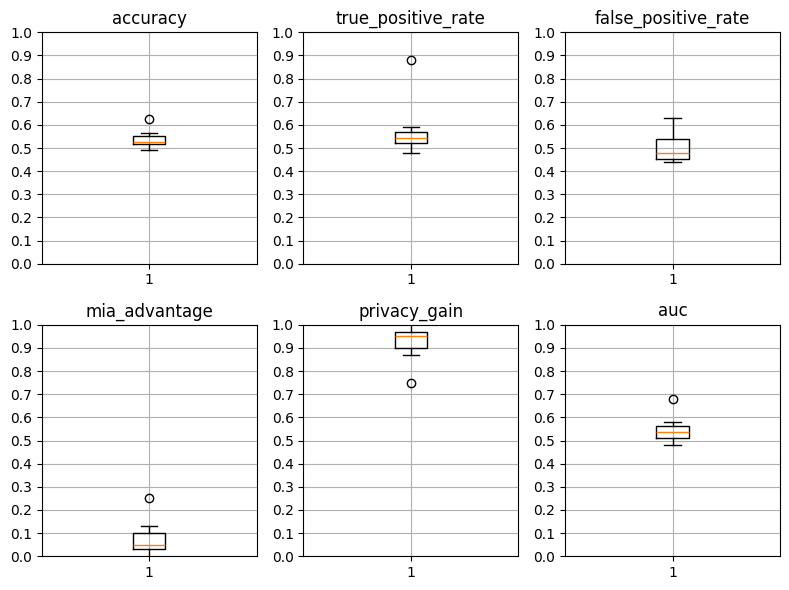

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')
from tools.utils import get_privacy_summaries, plot_privacy_metrics

SELECTED_GENERATORS = ['TabDDPM']
SELECTED_DATASETS = ['adult']

# Display the combined DataFrame
privacy_summaries = get_privacy_summaries('../experiments/privacy', SELECTED_DATASETS, SELECTED_GENERATORS)

# export to csv
privacy_summaries.to_csv(f"../generated/generators_comparison/adult_TabDDPM_privacy_results.csv")
plot_privacy_metrics(privacy_summaries)